# `RightCensoredObservedL1MLE` API Demo

This notebook demonstrates the package-level fixed-support observed-data estimator:

`from haldensity.censoring.right import RightCensoredObservedL1MLE`

The workflow is:

1. fit a Stage 1 `cv-IPCW` initializer,
2. compress the Stage 1 coefficient vector onto its selected working support,
3. refit the observed-data likelihood on that fixed support with `RightCensoredObservedL1MLE`,
4. compare a cold start against the natural Stage 1 warm start.

The main question here is practical rather than theoretical: **does the warm start help in this implementation?**

The notebook shows one representative seed in detail and then a small multi-seed summary.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists() and (p / "src").exists()
)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from haldensity.censoring.right import RightCensoredObservedL1MLE
from haldensity.censoring.right.comparison import (
    evaluate_survival_on_grid,
    simulate_beta_uniform_right_censored,
)
from haldensity.censoring.right.metrics import incomplete_loglik
from haldensity.censoring.tuners.right_tuners import RightCensoredInitTuner

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

REPRESENTATIVE_SEED = 3
N = 90
CV_FOLDS = 3
N_TRIALS = 6
N_GRID_POINTS = 100
STAGE1_OVERRIDES = {
    "basis_order": [0],
    "norm_constraint": {"low": 4.0, "high": 12.0, "log": False},
}
OBSERVED_L1_KWARGS = {
    "n_grid_points": N_GRID_POINTS,
    "learning_rate": 0.05,
    "n_iterations": 800,
    "ll_change_tol": 1e-4,
    "include_intercept_in_constraint": False,
    "history_every": 1,
}
SEED_SWEEP = list(range(1, 11))

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def fit_stage1_cv_ipcw(data: pd.DataFrame, *, seed: int):
    tuner = RightCensoredInitTuner(
        data=data,
        cv_folds=CV_FOLDS,
        random_state=seed,
        n_grid_points=N_GRID_POINTS,
        param_overrides=STAGE1_OVERRIDES,
        use_conservative_adjustment=False,
        silent=True,
        validation_metric="ipcw_loglik",
    )
    return tuner.optimize(n_trials=N_TRIALS)


def compress_theta_to_selected_support(estimator) -> np.ndarray:
    support = np.asarray(estimator.grid_points_hal_selected, dtype=float)
    all_knots = np.asarray(estimator._grid_points_hal, dtype=float)
    theta_full = np.asarray(estimator.theta_hat, dtype=float)
    basis_order = int(estimator.basis_order)
    poly_cols = basis_order if basis_order > 0 else 0
    knot_start = 1 + poly_cols

    theta_selected = np.zeros(knot_start + support.size, dtype=float)
    theta_selected[:knot_start] = theta_full[:knot_start]
    for i, knot in enumerate(support):
        idx = np.where(np.isclose(all_knots, knot, atol=1e-10, rtol=0.0))[0]
        if idx.size == 0:
            raise RuntimeError("selected support knot was not found in the full Stage 1 grid")
        theta_selected[knot_start + i] = theta_full[knot_start + int(idx[0])]
    return theta_selected


def fit_observed_l1(data: pd.DataFrame, stage1_estimator, *, use_warm_start: bool):
    warm_start = compress_theta_to_selected_support(stage1_estimator) if use_warm_start else None
    tic = time.perf_counter()
    estimator = RightCensoredObservedL1MLE(
        working_grid_points=np.asarray(stage1_estimator.grid_points_hal_selected, dtype=float),
        norm_constraint=float(stage1_estimator.norm_constraint),
        basis_order=int(stage1_estimator.basis_order),
        warm_start_theta=warm_start,
        **OBSERVED_L1_KWARGS,
    ).fit(data)
    runtime = time.perf_counter() - tic

    results = estimator.get_results()
    return {
        "estimator": estimator,
        "runtime_seconds": float(runtime),
        "results": results,
        "summary": {
            "warm_start": bool(use_warm_start),
            "runtime_seconds": float(runtime),
            "n_iterations_run": int(results["n_iterations_run"]),
            "converged": bool(results["converged"]),
            "observed_loglik": float(incomplete_loglik(estimator, data)),
            "penalized_l1_norm": float(results["penalized_l1_norm"]),
            "constraint_active": bool(results["constraint_active"]),
            "n_active_knot_coeffs": int(results["n_active_knot_coeffs"]),
            "reported_support_size": int(len(results["grid_points_hal_selected"])),
        },
    }


def history_to_frame(run: dict, label: str) -> pd.DataFrame:
    hist = pd.DataFrame(run["results"]["optimization_history"])
    if hist.empty:
        return hist
    hist = hist.copy()
    hist["run"] = label
    return hist


def improvement_table(seed_rows: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame(seed_rows)
    df["iteration_reduction"] = df["cold_iterations"] - df["warm_iterations"]
    df["runtime_reduction_ms"] = 1000.0 * (df["cold_runtime_seconds"] - df["warm_runtime_seconds"])
    df["loglik_gain_from_warm"] = df["warm_observed_loglik"] - df["cold_observed_loglik"]
    return df

In [3]:
simulation = simulate_beta_uniform_right_censored(n=N, seed=REPRESENTATIVE_SEED)
observed_data = simulation["observed_data"]
truth = simulation["truth"]

stage1_fit = fit_stage1_cv_ipcw(observed_data, seed=REPRESENTATIVE_SEED)
stage1_estimator = stage1_fit.estimator
stage1_support = np.asarray(stage1_estimator.grid_points_hal_selected, dtype=float).copy()
stage1_warm_start = compress_theta_to_selected_support(stage1_estimator)

stage1_summary = pd.DataFrame(
    [
        {
            "seed": REPRESENTATIVE_SEED,
            "n_observed": int(observed_data.shape[0]),
            "n_events": int(observed_data["Delta"].sum()),
            "n_censored": int((1 - observed_data["Delta"]).sum()),
            "stage1_basis_order": int(stage1_fit.best_params["basis_order"]),
            "stage1_norm_constraint": float(stage1_fit.best_params["norm_constraint"]),
            "stage1_support_size": int(stage1_support.size),
        }
    ]
)

display(observed_data.head())
display(stage1_summary)
print("Compressed warm-start length:", len(stage1_warm_start))

,T,Delta
0,0.241575,0
1,0.698215,0
2,0.266991,1
3,0.157021,0
4,0.128117,0


,seed,n_observed,n_events,n_censored,stage1_basis_order,stage1_norm_constraint,stage1_support_size
0,3,90,43,47,0,6.327238,12


Compressed warm-start length: 13


In [4]:
cold_run = fit_observed_l1(observed_data, stage1_estimator, use_warm_start=False)
warm_run = fit_observed_l1(observed_data, stage1_estimator, use_warm_start=True)

comparison_df = pd.DataFrame(
    [cold_run["summary"], warm_run["summary"]]
).assign(
    support_matches_stage1=lambda df: [
        np.array_equal(
            np.asarray(run["estimator"].grid_points_hal_selected, dtype=float),
            stage1_support,
        )
        for run in (cold_run, warm_run)
    ],
    grid_matches_stage1=lambda df: [
        np.array_equal(
            np.asarray(run["estimator"]._grid_points_hal, dtype=float),
            stage1_support,
        )
        for run in (cold_run, warm_run)
    ],
)

display(comparison_df)

print(
    "Warm-start iteration reduction:",
    int(cold_run["summary"]["n_iterations_run"] - warm_run["summary"]["n_iterations_run"]),
)
print(
    "Warm-start runtime reduction (ms):",
    round(1000.0 * (cold_run["summary"]["runtime_seconds"] - warm_run["summary"]["runtime_seconds"]), 2),
)
print(
    "Warm-start observed loglik gain:",
    round(warm_run["summary"]["observed_loglik"] - cold_run["summary"]["observed_loglik"], 6),
)

,warm_start,runtime_seconds,n_iterations_run,converged,observed_loglik,penalized_l1_norm,constraint_active,n_active_knot_coeffs,reported_support_size,support_matches_stage1,grid_matches_stage1
0,False,0.045581,253,True,1.177662,6.327238,True,11,12,True,True
1,True,0.014586,120,True,1.200844,6.327238,True,9,12,True,True


Warm-start iteration reduction: 133
Warm-start runtime reduction (ms): 30.99
Warm-start observed loglik gain: 0.023183


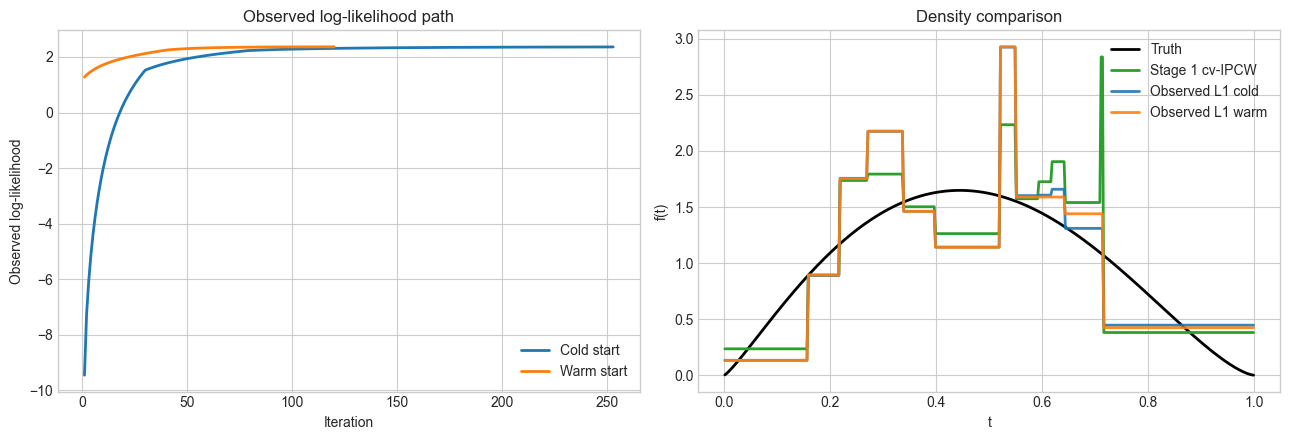

,t,truth,stage1,cold,warm
0,0.001000,0.999999,0.999765,0.999867,0.999868
1,0.003501,0.999981,0.999176,0.999533,0.999538
2,0.006003,0.999938,0.998588,0.999200,0.999208
3,0.008504,0.999868,0.998000,0.998867,0.998879
4,0.011005,0.999767,0.997411,0.998534,0.998549


In [5]:
history_df = pd.concat(
    [
        history_to_frame(cold_run, "Cold start"),
        history_to_frame(warm_run, "Warm start"),
    ],
    ignore_index=True,
)

eval_grid = np.linspace(0.001, 0.999, 400)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for label, color in [("Cold start", "tab:blue"), ("Warm start", "tab:orange")]:
    sub = history_df[history_df["run"] == label]
    axes[0].plot(sub["iteration"], sub["log_likelihood"], linewidth=2, label=label, color=color)
axes[0].set_title("Observed log-likelihood path")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Observed log-likelihood")
axes[0].legend()

axes[1].plot(eval_grid, truth.density_fn(eval_grid), color="black", linewidth=2, label="Truth")
axes[1].plot(eval_grid, stage1_estimator.get_density_at_points(eval_grid), color="tab:green", linewidth=2, label="Stage 1 cv-IPCW")
axes[1].plot(eval_grid, cold_run["estimator"].get_density_at_points(eval_grid), color="tab:blue", linewidth=2, alpha=0.9, label="Observed L1 cold")
axes[1].plot(eval_grid, warm_run["estimator"].get_density_at_points(eval_grid), color="tab:orange", linewidth=2, alpha=0.9, label="Observed L1 warm")
axes[1].set_title("Density comparison")
axes[1].set_xlabel("t")
axes[1].set_ylabel("f(t)")
axes[1].legend()

plt.tight_layout()
plt.show()

survival_df = pd.DataFrame(
    {
        "t": eval_grid,
        "truth": truth.survival_fn(eval_grid),
        "stage1": evaluate_survival_on_grid(stage1_estimator, eval_grid),
        "cold": evaluate_survival_on_grid(cold_run["estimator"], eval_grid),
        "warm": evaluate_survival_on_grid(warm_run["estimator"], eval_grid),
    }
)

display(survival_df.head())

,seed,support_size,cold_iterations,warm_iterations,cold_runtime_seconds,warm_runtime_seconds,cold_observed_loglik,warm_observed_loglik,iteration_reduction,runtime_reduction_ms,loglik_gain_from_warm
0,1,11,306,189,0.039794,0.025452,-4.478633,-4.481309,117,14.342084,-0.002676
1,2,10,182,140,0.019966,0.015383,-1.023170,-0.995012,42,4.583417,0.028158
2,3,12,253,120,0.032500,0.015854,1.177662,1.200844,133,16.646792,0.023183
3,4,12,438,200,0.052340,0.025533,-4.330186,-4.224400,238,26.807458,0.105786
4,5,10,518,151,0.073247,0.025560,-1.801885,-1.775673,367,47.686625,0.026212
5,6,8,218,140,0.023151,0.014572,-6.713140,-6.691270,78,8.578624,0.021870
6,7,10,133,98,0.014689,0.011082,1.180807,1.296255,35,3.606334,0.115448
7,8,8,62,49,0.007680,0.006077,8.272086,8.331252,13,1.602959,0.059167
8,9,9,128,142,0.016293,0.018558,-3.128839,-3.241598,-14,-2.265125,-0.112759
9,10,12,234,80,0.025590,0.010300,1.123893,1.130849,154,15.289625,0.006955


,n_seeds,warm_fewer_iterations,warm_faster_runtime,warm_higher_observed_loglik,median_iteration_reduction,median_runtime_reduction_ms,median_loglik_gain_from_warm
0,10,9,9,8,97.5,11.460354,0.024697


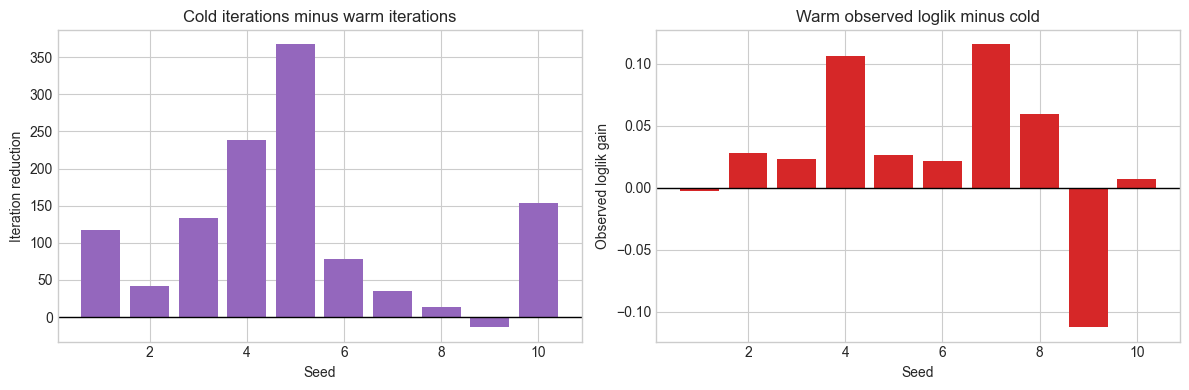

In [6]:
seed_rows = []
for seed in SEED_SWEEP:
    data_seed = simulate_beta_uniform_right_censored(n=N, seed=seed)["observed_data"]
    stage1_seed = fit_stage1_cv_ipcw(data_seed, seed=seed).estimator
    cold_seed = fit_observed_l1(data_seed, stage1_seed, use_warm_start=False)
    warm_seed = fit_observed_l1(data_seed, stage1_seed, use_warm_start=True)
    seed_rows.append(
        {
            "seed": seed,
            "support_size": int(len(stage1_seed.grid_points_hal_selected)),
            "cold_iterations": int(cold_seed["summary"]["n_iterations_run"]),
            "warm_iterations": int(warm_seed["summary"]["n_iterations_run"]),
            "cold_runtime_seconds": float(cold_seed["summary"]["runtime_seconds"]),
            "warm_runtime_seconds": float(warm_seed["summary"]["runtime_seconds"]),
            "cold_observed_loglik": float(cold_seed["summary"]["observed_loglik"]),
            "warm_observed_loglik": float(warm_seed["summary"]["observed_loglik"]),
        }
    )

seed_summary = improvement_table(seed_rows)
seed_overview = pd.DataFrame(
    [
        {
            "n_seeds": int(seed_summary.shape[0]),
            "warm_fewer_iterations": int(np.sum(seed_summary["iteration_reduction"] > 0)),
            "warm_faster_runtime": int(np.sum(seed_summary["runtime_reduction_ms"] > 0)),
            "warm_higher_observed_loglik": int(np.sum(seed_summary["loglik_gain_from_warm"] > 0)),
            "median_iteration_reduction": float(np.median(seed_summary["iteration_reduction"])),
            "median_runtime_reduction_ms": float(np.median(seed_summary["runtime_reduction_ms"])),
            "median_loglik_gain_from_warm": float(np.median(seed_summary["loglik_gain_from_warm"])),
        }
    ]
)

display(seed_summary)
display(seed_overview)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].bar(seed_summary["seed"], seed_summary["iteration_reduction"], color="tab:purple")
axes[0].set_title("Cold iterations minus warm iterations")
axes[0].set_xlabel("Seed")
axes[0].set_ylabel("Iteration reduction")

axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].bar(seed_summary["seed"], seed_summary["loglik_gain_from_warm"], color="tab:red")
axes[1].set_title("Warm observed loglik minus cold")
axes[1].set_xlabel("Seed")
axes[1].set_ylabel("Observed loglik gain")

plt.tight_layout()
plt.show()

## Reading the result

For this implementation, the Stage 1 warm start is best viewed as an optimization aid rather than a guaranteed statistical improvement.

Typical pattern in the small sweep above:

- warm start often reduces the number of projected-gradient iterations,
- warm start often reduces wall-clock time,
- warm start often improves the final observed log-likelihood slightly,
- but not on every seed.

So the practical answer is: **yes, warm start usually helps with optimization efficiency here, but it is not universally better on every run under the current optimizer and stopping rule.**